In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Veriyi yükleyelim
data = pd.read_csv('veri.csv')
print("Veri Başarıyla Yüklendi!")
data.head()

Veri Başarıyla Yüklendi!


,Marka,Model,Guvenlik_Puani,Konfor_Puani,Fiyat_TL,Gurultu_dB
0,Michelin,Alpin 6,9.5,9.8,4500,68
1,Continental,TS 870,9.8,9.2,4300,70
2,Bridgestone,LM005,9.6,9.0,4100,71
3,Goodyear,UG Perf 3,9.4,9.3,3900,69
4,Lassa,Snoways 4,8.5,8.2,2500,72


In [2]:
print("--- Temel İstatistikler ---")
print(data.describe())

print("\n--- Eksik Veri Kontrolü ---")
print(data.isnull().sum())

--- Temel İstatistikler ---
       Guvenlik_Puani  Konfor_Puani     Fiyat_TL  Gurultu_dB
count        7.000000      7.000000     7.000000    7.000000
mean         9.257143      9.000000  3742.857143   69.857143
std          0.461364      0.525991   692.476577    1.345185
min          8.500000      8.200000  2500.000000   68.000000
25%          9.000000      8.750000  3450.000000   69.000000
50%          9.400000      9.000000  3900.000000   70.000000
75%          9.550000      9.250000  4200.000000   70.500000
max          9.800000      9.800000  4500.000000   72.000000

--- Eksik Veri Kontrolü ---
Marka             0
Model             0
Guvenlik_Puani    0
Konfor_Puani      0
Fiyat_TL          0
Gurultu_dB        0
dtype: int64


In [3]:
print("--- Korelasyon Matrisi ---")
# Sadece sayısal sütunları seçerek korelasyon hesaplayalım
numeric_data = data.select_dtypes(include=['float64', 'int64'])
print(numeric_data.corr())

--- Korelasyon Matrisi ---
                Guvenlik_Puani  Konfor_Puani  Fiyat_TL  Gurultu_dB
Guvenlik_Puani        1.000000      0.810416  0.950938   -0.468041
Konfor_Puani          0.810416      1.000000  0.928884   -0.824435
Fiyat_TL              0.950938      0.928884  1.000000   -0.672232
Gurultu_dB           -0.468041     -0.824435 -0.672232    1.000000


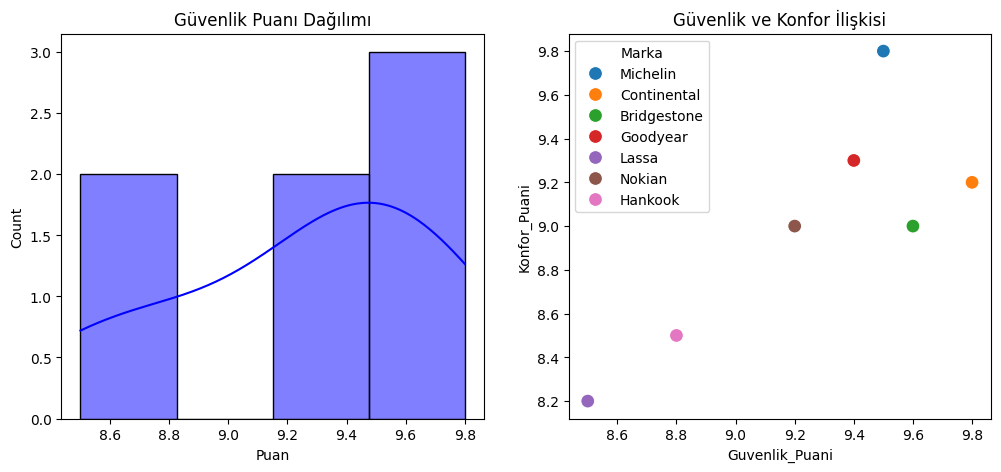

In [4]:
plt.figure(figsize=(12, 5))

# Histogram: Güvenlik Puanı Dağılımı
plt.subplot(1, 2, 1)
sns.histplot(data['Guvenlik_Puani'], kde=True, color='blue')
plt.title('Güvenlik Puanı Dağılımı')
plt.xlabel('Puan')

# Scatter Plot: Güvenlik vs Konfor
plt.subplot(1, 2, 2)
sns.scatterplot(data=data, x='Guvenlik_Puani', y='Konfor_Puani', hue='Marka', s=100)
plt.title('Güvenlik ve Konfor İlişkisi')
plt.show()

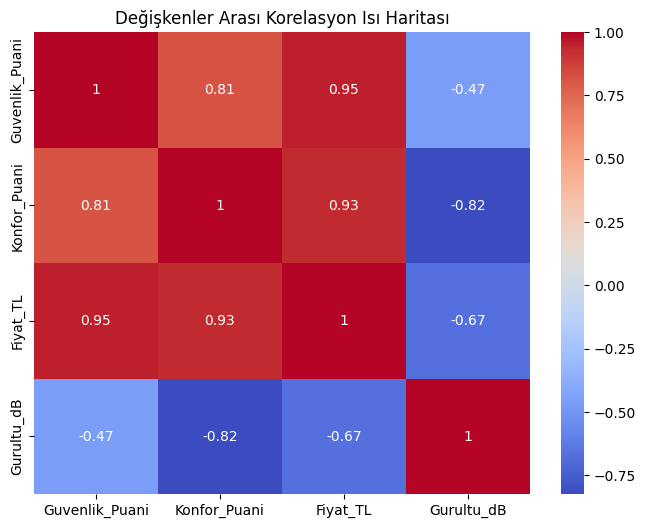

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Değişkenler Arası Korelasyon Isı Haritası')
plt.show()